In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from src.data_import import load_fashion_mnist

train_loader, test_loader = load_fashion_mnist(32, shuffle=True, class_subset=[9])

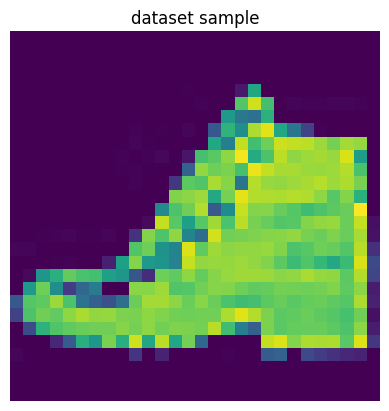

label: 9


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample")
#print label
print("label:", _[0].item())

In [4]:
from src.model import EnergyHead, EBM

model = EBM(in_dim=28*28, mid_dim=150, n_heads=3, batch_size=32)

model.to(device)
for h in model.heads:
    h.to(device)

In [ ]:
from src.sampler import ReplaySampler

sampler = ReplaySampler(model, img_shape=(1, 28, 28), buffer_size=200, noise_fraction=0.05, device=device)

neg_samples = sampler.sample(batch_size=32, steps=10, step_size=0.1, noise_std=0.1)


In [7]:
from src.train import train_one_epoch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.0, 0.999))

for epoch in range(20):
    epoch_loss = train_one_epoch(model, sampler, train_loader, optimizer,
                                 sample_steps=60,
                                 sample_step_size=10.0,
                                 sample_noise_std=0.005,
                                 energy_reg=0.5,
                                 corr_param=0.1,
                                 device=device)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

100%|██████████| 188/188 [06:09<00:00,  1.96s/it]


  CD:     1.0999
  Reg:    5.7253
  Corr:   0.0764
  E_real: -0.2994
  E_fake: -1.3994
  Gap:    1.1000
Epoch 1, Loss: 6.9016


100%|██████████| 188/188 [05:55<00:00,  1.89s/it]


  CD:     0.5614
  Reg:    0.3068
  Corr:   0.0396
  E_real: 0.2659
  E_fake: -0.2955
  Gap:    0.5614
Epoch 2, Loss: 0.9078


100%|██████████| 188/188 [05:55<00:00,  1.89s/it]


...

  CD:     0.0192
  Reg:    0.0006
  Corr:   0.0364
  E_real: 0.0102
  E_fake: -0.0090
  Gap:    0.0192
Epoch 18, Loss: 0.0562


100%|██████████| 188/188 [05:53<00:00,  1.88s/it]


  CD:     0.0169
  Reg:    0.0005
  Corr:   0.0356
  E_real: 0.0088
  E_fake: -0.0081
  Gap:    0.0169
Epoch 19, Loss: 0.0530


100%|██████████| 188/188 [06:01<00:00,  1.92s/it]

  CD:     0.0149
  Reg:    0.0007
  Corr:   0.0357
  E_real: 0.0078
  E_fake: -0.0070
  Gap:    0.0149
Epoch 20, Loss: 0.0512


EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0053,  std=0.0094
  Test   →  mean=0.0055,  std=0.0137
  |E_test - E_train| = 0.0002  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0104,  std=0.0058
  Gap (E_real_train - E_fake) = 0.0157  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=1.5776,  std=0.0929
  Gap (E_real_train - E_noise) = -1.5723  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.0784,  std=0.0507
  Head 1  →  mean=0.8683,  std=0.0431
  Head 2  →  mean=-0.7854,  std=0.0417
  Max off-diagonal correlation: 0.6785  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 200 / 200
  Buffer samples  →  mean=0.3045,  std=0.3746,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


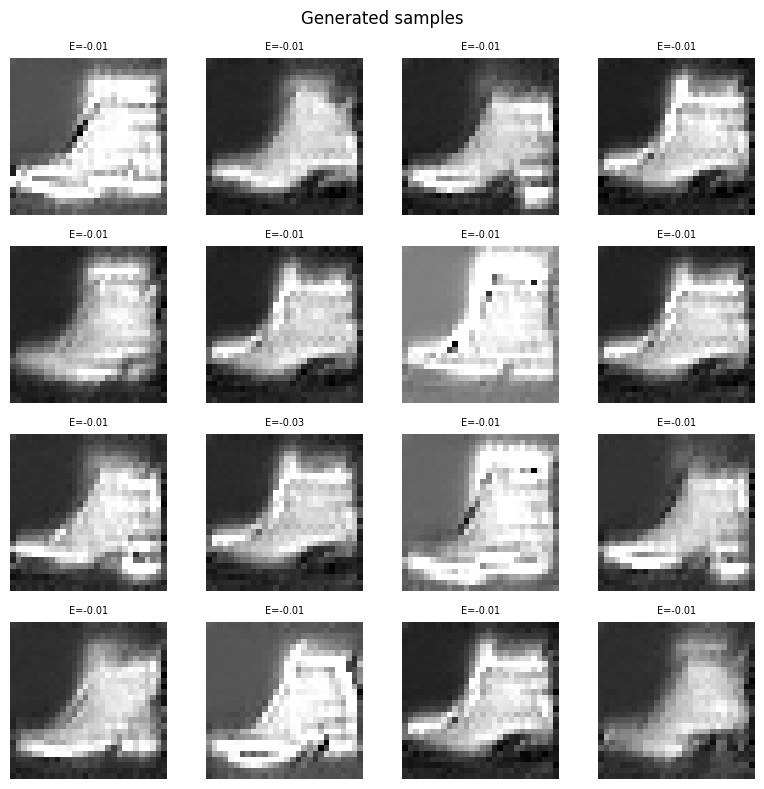


DONE


In [8]:
from src.diagnostic import diagnose

diagnose(model, sampler, train_loader, test_loader, device=device, n_samples=16)

In [13]:
samples = sampler.generate(10, steps=200, step_size=10, noise_std=0.005)

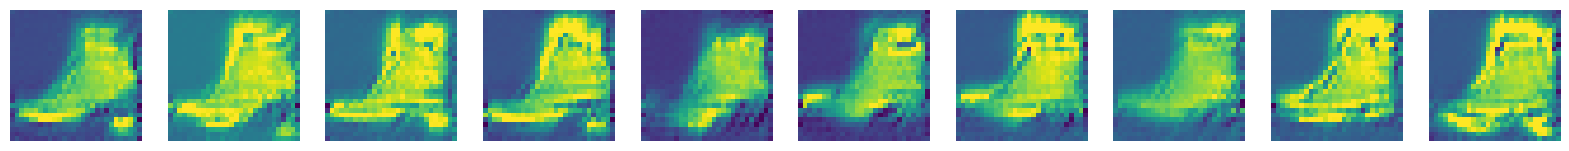

In [14]:
show_grid(samples, 10)